In [1]:
import ultranest
import george
import numpy as np
import matplotlib.pyplot as plt
from ultranest.plot import cornerplot
from ultranest import ReactiveNestedSampler
from ultranest.plot import PredictionBand

In [4]:
filename = 'Land_and_Ocean_complete.txt'
separator = "% Global Average Temperature Anomaly with Sea Ice Temperature Inferred from Water Temperatures"

with open(filename, 'r') as f:
    content = f.read()

parts = content.split(separator)

with open('data_air.txt', 'w') as f:
    f.write(parts[0])

with open('data_water.txt', 'w') as f:
    f.write(separator + parts[1])

data_air_raw = np.genfromtxt('data_air.txt', comments='%', filling_values=np.nan)
data_water_raw = np.genfromtxt('data_water.txt', comments='%', filling_values=np.nan)

print("File creati e caricati correttamente!")
def to_dict(raw):
    # Tempo in anni decimali: Anno + (Mese - 0.5)/12
    years = raw[:, 0]
    months = raw[:, 1]
    time_years = years + (months - 0.5) / 12
    t_ref = np.min(years)
    time_centered = time_years - t_ref
    return {
        "time_years": time_years,
        "time_centered": time_centered,
        "Year": raw[:,0].astype(int), 
        "Month": raw[:,1].astype(int), 
        "Monthly_Anomaly": raw[:,2], 
        "Monthly_Anomaly_Unc": raw[:,3], 
        "Annual_Anomaly": raw[:,4], 
        "Annual_Anomaly_Unc": raw[:,5], 
        "Five_Year_Anomaly": raw[:,6], 
        "Five_Year_Anomaly_Unc": raw[:,7], 
        "Ten_Year_Anomaly": raw[:,8], 
        "Ten_Year_Anomaly_Unc": raw[:,9], 
        "Twenty_Year_Anomaly": raw[:,10], 
        "Twenty_Year_Anomaly_Unc": raw[:,11], 
    }

data_air = to_dict(data_air_raw)
data_water = to_dict(data_water_raw)

print(f"Mesi caricati (Sezione Aria): {len(data_air['Year'])}")
print(f"Mesi caricati (Sezione Acqua): {len(data_water['Year'])}")

File creati e caricati correttamente!
Mesi caricati (Sezione Aria): 2100
Mesi caricati (Sezione Acqua): 2100


In [5]:
def constant_model(t, intercept):
    return intercept + t*0

def linear_model(t, a, b):
    return b + a*t

def quadratic_model(t, a, b, c):
    return c + b*t + a*t**2

def exponential_model(t, a, b, c):
    return a * np.exp(b*t) + c

In [6]:
param_constant = ['intercept']
param_linear = ['a', 'b']
param_quadratic = ['a', 'b', 'c']
param_exponential = ['a', 'b', 'c']

def prior_constant(cube):

    params = cube.copy()

    params[0] = cube[0] * 20 - 10

    return params

def prior_linear(cube):

    params = cube.copy()

    params[0] = cube[0] * 1
    params[1] = cube[1] * 10 - 5

    return params

def prior_quadratic(cube):

    params = cube.copy()

    params[0] = (cube[0] * 0.002) - 0.001
    params[1] = (cube[1] * 0.2) - 0.1
    params[2] = (cube[2] * 4) - 2

    return params

def prior_exponential(cube):

    params = cube.copy()

    params[0] = cube[0] * 2.0
    params[1] = cube[1] * 0.05
    params[2] = (cube[2] * 2.0) - 2.0
    
    return params

def log_likelihood_constant(params, data):
    
    intercept = params

    model = constant_model(data['time_centered'], intercept)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_linear(params, data):
    
    a, b = params

    model = linear_model(data['time_centered'], a, b)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2)

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_quadratic(params, data):
    
    a, b, c = params

    model = quadratic_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

def log_likelihood_exponential(params, data):
    
    a, b, c = params

    model = exponential_model(data['time_centered'], a, b, c)

    residuals = data['Annual_Anomaly'] - model

    chi2 = np.nansum((residuals / data['Annual_Anomaly_Unc'])**2+np.log(2*np.pi*data['Annual_Anomaly_Unc']**2))

    loglike = -0.5 * chi2

    return loglike

In [7]:
datasets = {
    'air': data_air,
    'water': data_water
}

models_config = {
    'const': (param_constant, log_likelihood_constant, prior_constant),
    'linear': (param_linear, log_likelihood_linear, prior_linear),
    'quadratic': (param_quadratic, log_likelihood_quadratic, prior_quadratic),
    'exponential': (param_exponential, log_likelihood_exponential, prior_exponential),
}

results = {}
samplers = {}

for model_label, (params, loglike_fn, prior_fn) in models_config.items():
    for data_label, data in datasets.items():
        
        run_id = f"{data_label}_{model_label}" 
        print(f"STARTING RUN: {run_id.upper()}")
        
        sampler = ReactiveNestedSampler(
            params, 
            lambda p, d=data: loglike_fn(p, d), 
            prior_fn
        )
        
        res = sampler.run(min_num_live_points=400, dKL=np.inf, min_ess=100)

        samplers[run_id] = sampler
        results[run_id] = res
        
        print(f"\nDONE: {run_id}")
        sampler.print_results()

STARTING RUN: AIR_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-8e+04  -81416.72 [-81416.7252..-81416.7252]*| it/evals=4880/5464 eff=96.3665% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5503
[ultranest]   logZ = -8.143e+04 +- 0.1143
[ultranest] Effective samples strategy satisfied (ESS = 1257.0, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.12, need <0.5)
[ultranest]   logZ error budget: single: 0.15 bs:0.11 tail:0.03 total:0.12 required:<0.50
[ultranest] done iterating.

DONE: air_const

logZ = -81425.662 +- 0.268
  single instance: logZ = -81425.662 +- 0.145
  bootstrapped   : logZ = -81425.654 +- 0.265
  tail           : logZ = +- 0.034
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.3447│ ▁ ▁▁▁▁▁▁▁▂▂▂▃▅▅▇▆▇▇▇▇▆▅▄▄▃▃▁▁▁▁▁▁▁▁ ▁ │0.3532    0.3490 +- 0.0010

STARTING RUN: WATER_CONST
[ultranest] Sampling 400 live points from prior ...


[ultranest] Explored until L=-7e+04  -74211.44 [-74211.4404..-74211.4404]*| it/evals=4800/5370 eff=96.5795% N=400 0  0  0  
[ultranest] Likelihood function evaluations: 5371
[ultranest]   logZ = -7.422e+04 +- 0.1199
[ultranest] Effective samples strategy satisfied (ESS = 1244.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.45+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.13, need <0.5)
[ultranest]   logZ error budget: single: 0.14 bs:0.12 tail:0.04 total:0.13 required:<0.50
[ultranest] done iterating.

DONE: water_const

logZ = -74220.271 +- 0.293
  single instance: logZ = -74220.271 +- 0.145
  bootstrapped   : logZ = -74220.270 +- 0.290
  tail           : logZ = +- 0.041
insert order U test : converged: True correlation: inf iterations

    intercept           : 0.31563│ ▁▁▁▁▁▁▁▁▂▂▄▄▅▅▅▆▇▇▇▅▅▅▄▃▃▂▂▁▁▁▁▁▁▁▁ ▁ │0.32340    0.31925 +- 0.00095

STARTING RUN: AIR_LINEAR
[ultranest] Sampling 400 live points from prior .

[ultranest] Explored until L=-2e+04  -20185.62 [-20185.6255..-20185.6254]*| it/evals=9090/12358 eff=76.0161% N=400    0   0 
[ultranest] Likelihood function evaluations: 12382
[ultranest]   logZ = -2.02e+04 +- 0.1452
[ultranest] Effective samples strategy satisfied (ESS = 1589.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.15, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.15 tail:0.01 total:0.15 required:<0.50
[ultranest] done iterating.

DONE: air_linear

logZ = -20203.787 +- 0.234
  single instance: logZ = -20203.787 +- 0.207
  bootstrapped   : logZ = -20203.814 +- 0.234
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009910│ ▁▁▁▁▁▁▁▁▁▂▂▄▄▆▆▆▇▇▇▆▆▅▅▄▃▂▁▁▁▁▁▁▁▁▁ ▁ │0.010148    0.010024 +- 0.000028
    b                   : -0.9844│ ▁▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▇▇▆▇▇▇▇▅▅▄▃▁▁▁▁▁▁▁▁▁

[ultranest] Explored until L=-2e+04  -18230.81 [-18230.8218..-18230.8218]*| it/evals=8960/12244 eff=75.6501% N=400    0   0 
[ultranest] Likelihood function evaluations: 12281
[ultranest]   logZ = -1.825e+04 +- 0.142
[ultranest] Effective samples strategy satisfied (ESS = 1610.6, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.14, need <0.5)
[ultranest]   logZ error budget: single: 0.21 bs:0.14 tail:0.01 total:0.14 required:<0.50
[ultranest] done iterating.

DONE: water_linear

logZ = -18248.682 +- 0.309
  single instance: logZ = -18248.682 +- 0.205
  bootstrapped   : logZ = -18248.652 +- 0.309
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.009020│ ▁ ▁▁▁▁▁▁▁▂▂▃▄▅▇▇▇▇▇▆▅▅▃▃▁▁▁▁▁▁▁▁    ▁ │0.009285    0.009144 +- 0.000026
    b                   : -0.9141│ ▁    ▁▁▁▁▁▁▁▂▂▃▅▅▅▆▇▇▇▆▅▄▃▂▂▁▁▁▁▁▁

[ultranest] Explored until L=-2e+03  138.32 [-2138.3749..-2138.3748]*| it/evals=10760/18496 eff=59.4607% N=400   0   0   0  
[ultranest] Likelihood function evaluations: 18501
[ultranest]   logZ = -2161 +- 0.1731
[ultranest] Effective samples strategy satisfied (ESS = 1906.5, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.47+-0.07 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.15 to 0.51, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.17 tail:0.01 total:0.17 required:<0.50
[ultranest] done iterating.

DONE: air_quadratic

logZ = -2160.659 +- 0.513
  single instance: logZ = -2160.659 +- 0.228
  bootstrapped   : logZ = -2160.609 +- 0.513
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00009947│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▅▅▆▇▇▇▇▇▆▆▄▃▃▂▂▁▁▁▁▁▁ ▁ │0.00010460    0.00010218 +- 0.00000062
    b                   : -0.01198│ ▁

[ultranest] Explored until L=-2e+03  948.94 [-1948.9968..-1948.9965]*| it/evals=10960/18738 eff=59.7666% N=400   0   400 0  
[ultranest] Likelihood function evaluations: 18750
[ultranest]   logZ = -1972 +- 0.161
[ultranest] Effective samples strategy satisfied (ESS = 1868.4, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.09 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.23 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: water_quadratic

logZ = -1971.778 +- 0.412
  single instance: logZ = -1971.778 +- 0.231
  bootstrapped   : logZ = -1971.780 +- 0.412
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.00008735│ ▁▁▁▁▁▁▁▁▁▂▂▃▃▄▅▆▆▇▇▆▇▅▅▃▃▂▂▁▁▁▁▁▁▁ ▁▁ │0.00009211    0.00008970 +- 0.00000057
    b                   : -0.01028│ ▁▁▁▁▁▁▁▁▁▁▂▂▂▃▄▅▆▆▇▆▇▇▆▅▄▃▃▂▂▁

[ultranest] Explored until L=-2e+03  681.17 [-1681.2294..-1681.2293]*| it/evals=10120/96832 eff=10.4944% N=400   0  0 
[ultranest] Likelihood function evaluations: 96871
[ultranest]   logZ = -1702 +- 0.1616
[ultranest] Effective samples strategy satisfied (ESS = 1947.2, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.08 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy is satisfied (dlogz=0.16, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.16 tail:0.01 total:0.16 required:<0.50
[ultranest] done iterating.

DONE: air_exponential

logZ = -1701.956 +- 0.483
  single instance: logZ = -1701.956 +- 0.219
  bootstrapped   : logZ = -1701.944 +- 0.483
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.02969│ ▁▁▁▁▁▁▁▁▁▃▂▄▅▅▆▆▇▇▇▇▆▆▅▄▄▂▂▂▁▁▁▁▁▁▁▁▁ │0.03719    0.03334 +- 0.00095
    b                   : 0.02151│ ▁▁▁▁▁▁▁▁▁▂▃▄▄▅▅▇▇▆▇▇▆▅▅▅▄▃▂▂▁▁▁▁▁▁▁ ▁ │0.02271  

[ultranest] Explored until L=-2e+03  687.33 [-1687.3837..-1687.3837]*| it/evals=10080/107777 eff=9.3875% N=400   0  0  
[ultranest] Likelihood function evaluations: 107838
[ultranest]   logZ = -1708 +- 0.2034
[ultranest] Effective samples strategy satisfied (ESS = 1868.1, need >100)
[ultranest] Posterior uncertainty strategy is satisfied (KL: 0.46+-0.06 nat, need <inf nat)
[ultranest] Evidency uncertainty strategy wants 398 minimum live points (dlogz from 0.16 to 0.51, need <0.5)
[ultranest]   logZ error budget: single: 0.22 bs:0.20 tail:0.01 total:0.20 required:<0.50
[ultranest] done iterating.

DONE: water_exponential

logZ = -1708.050 +- 0.513
  single instance: logZ = -1708.050 +- 0.219
  bootstrapped   : logZ = -1708.038 +- 0.513
  tail           : logZ = +- 0.010
insert order U test : converged: True correlation: inf iterations

    a                   : 0.0304│ ▁   ▁▁▁▁▁▁▂▂▃▃▅▇▇▇▇▆▅▅▄▃▂▂▂▁▁▁▁▁▁▁  ▁ │0.0402    0.0352 +- 0.0010
    b                   : 0.02048│ ▁  ▁▁▁▁▁▁▂▂▂▄▄▆▆▇▇

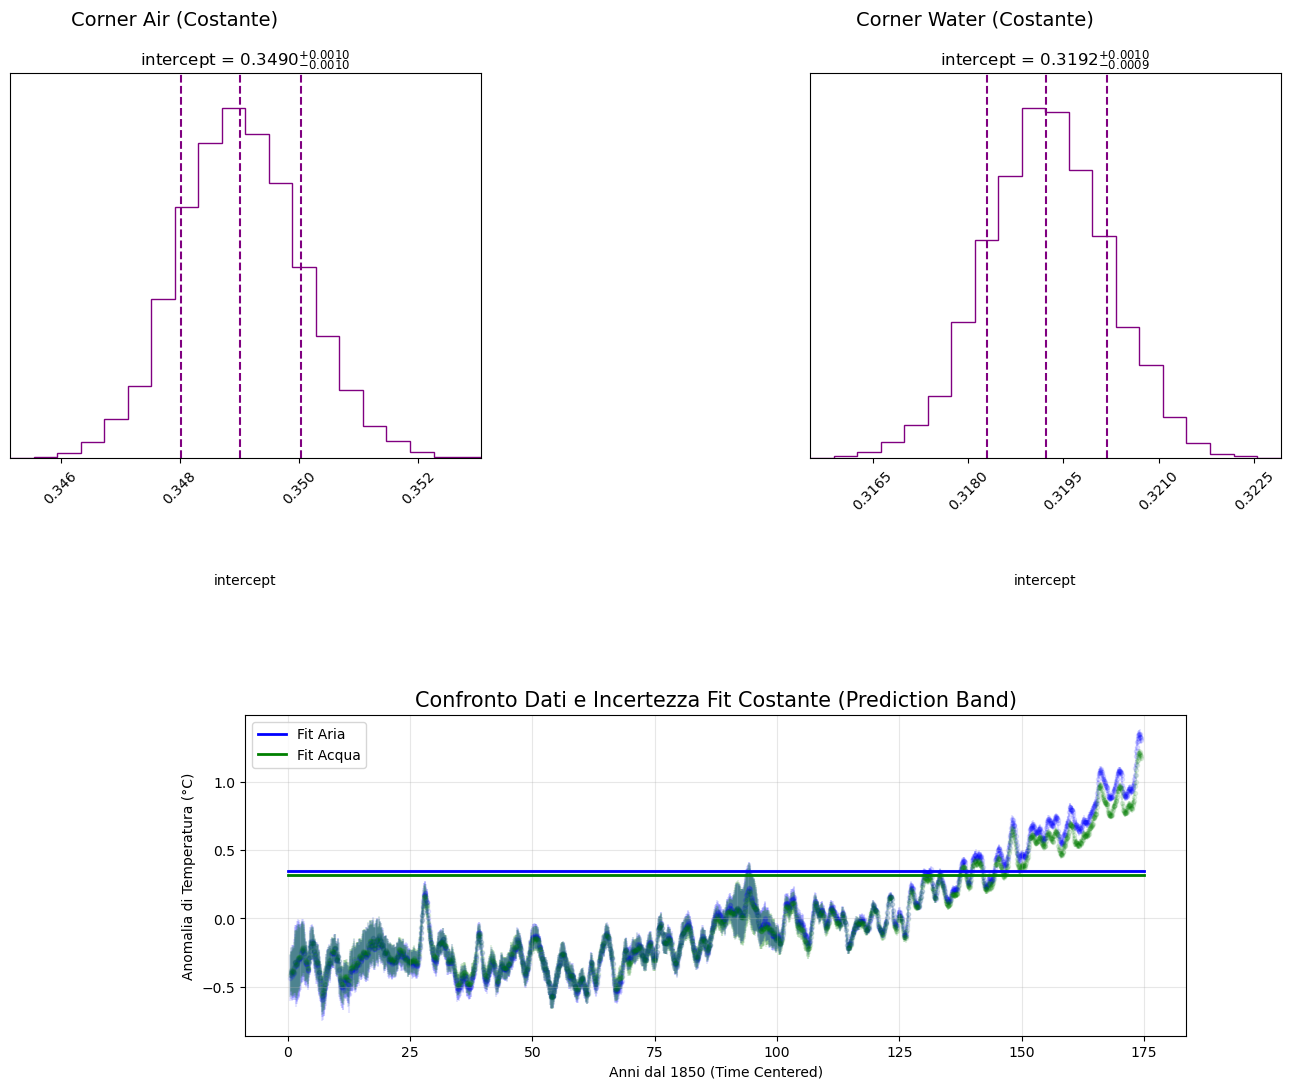

In [8]:
fig = plt.figure(figsize=(16, 12))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.2, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_const'], fig=corner_subfigs[0], title_fmt='.4f')
corner_subfigs[0].suptitle('Corner Air (Costante)', fontsize=14)

cornerplot(results['water_const'], fig=corner_subfigs[1], title_fmt='.4f')
corner_subfigs[1].suptitle('Corner Water (Costante)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def add_constant_band(ax, res_key, data, color, label_name):
    samples = results[res_key]['samples']
    band = PredictionBand(t_grid)
    
    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        val = samples[i]
        band.add(np.full_like(t_grid, val))
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Fit {label_name}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma (95% approx)

add_constant_band(ax, 'air_const', data_air, 'blue', 'Aria')
add_constant_band(ax, 'water_const', data_water, 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Costante (Prediction Band)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

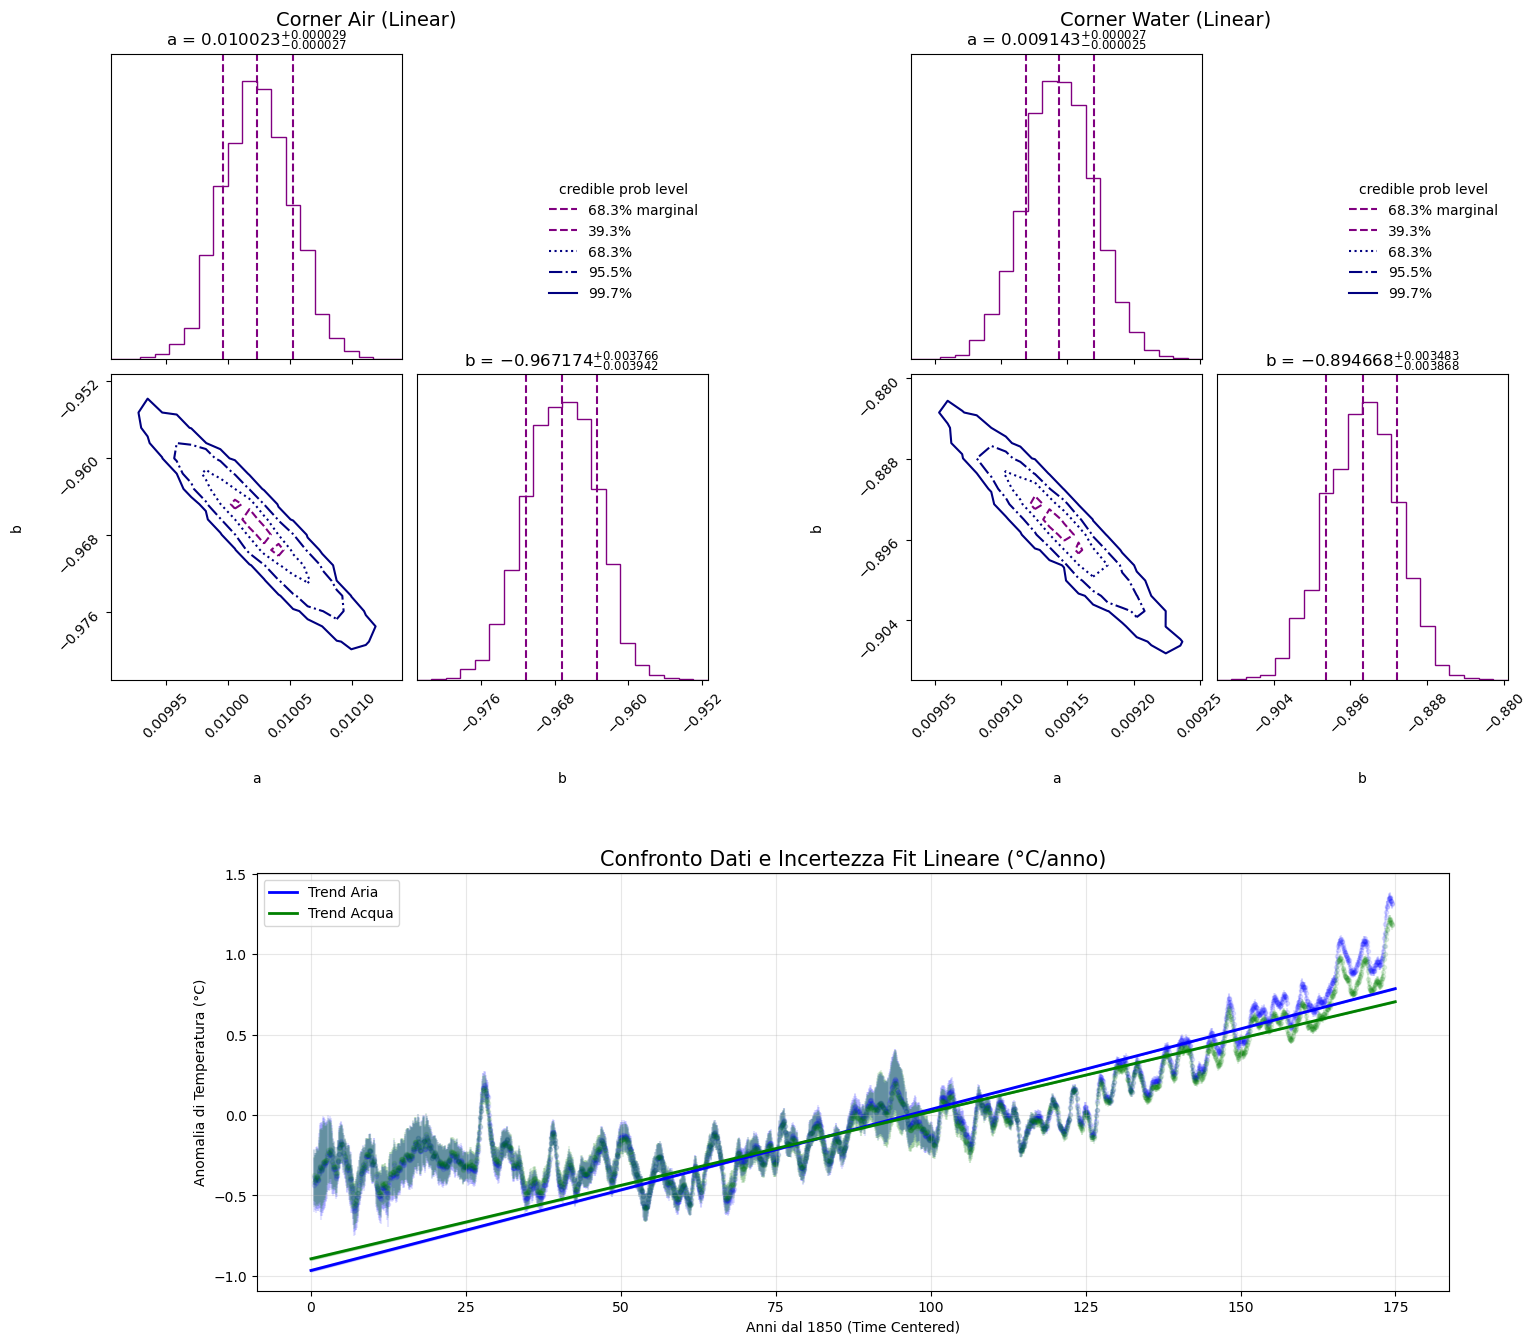

In [9]:
fig = plt.figure(figsize=(16, 14))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.5, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_linear'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Linear)', fontsize=14)

cornerplot(results['water_linear'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Linear)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_linear_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b = samples[i]
        band.add(a * t_grid + b)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2, label=f'Trend {label_prefix}', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)        # 1-sigma
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2) # 2-sigma

plot_linear_with_bands(ax, data_air, 'air_linear', 'blue', 'Aria')
plot_linear_with_bands(ax, data_water, 'water_linear', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Lineare (°C/anno)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

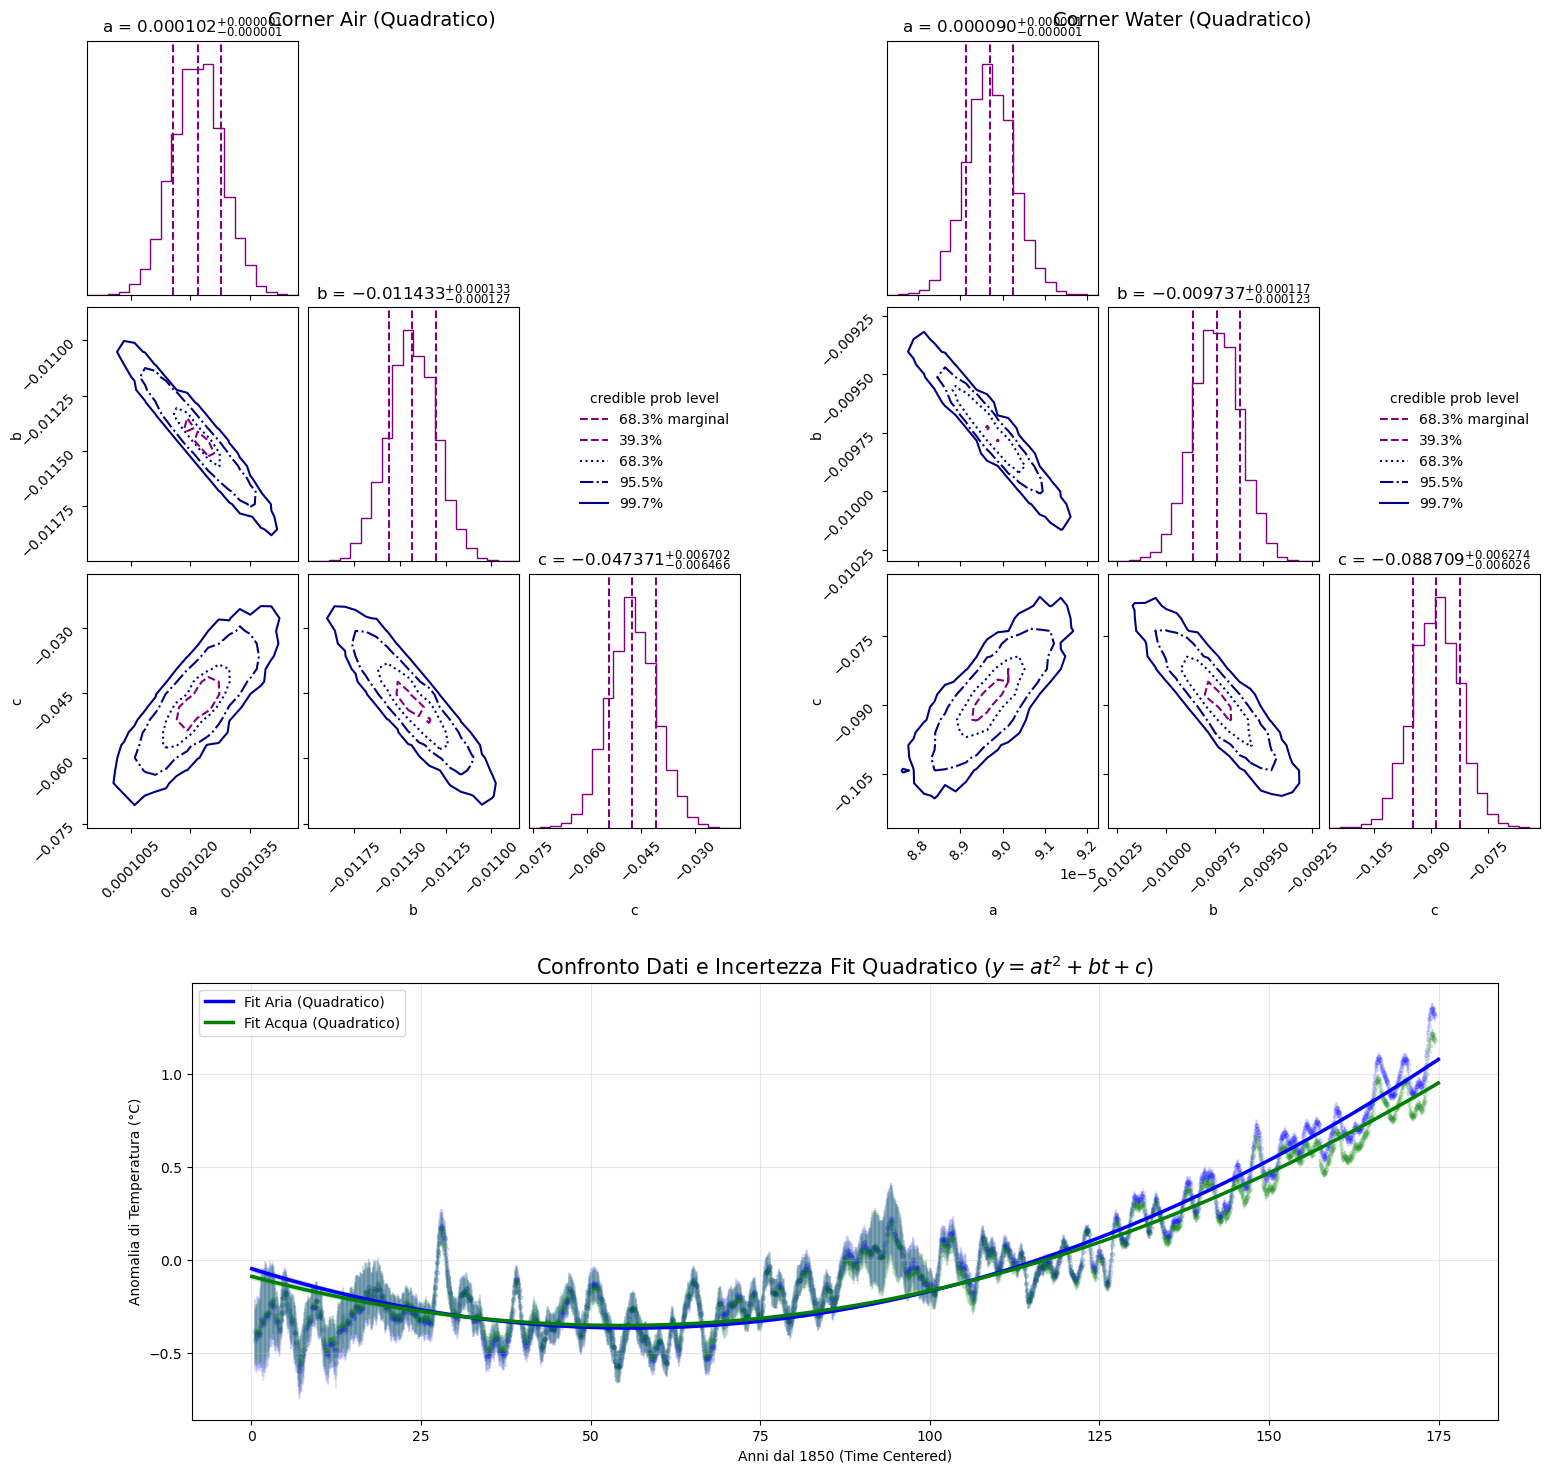

In [10]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_quadratic'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Quadratico)', fontsize=14)

cornerplot(results['water_quadratic'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Quadratico)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_quadratic_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']
    
    band = PredictionBand(t_grid)
    
    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b, c = samples[i]
        band.add(a * t_grid**2 + b * t_grid + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)

    band.line(ax=ax, color=color, lw=2.5, label=f'Fit {label_prefix} (Quadratico)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_quadratic_with_bands(ax, data_air, 'air_quadratic', 'blue', 'Aria')
plot_quadratic_with_bands(ax, data_water, 'water_quadratic', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Quadratico ($y = at^2 + bt + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

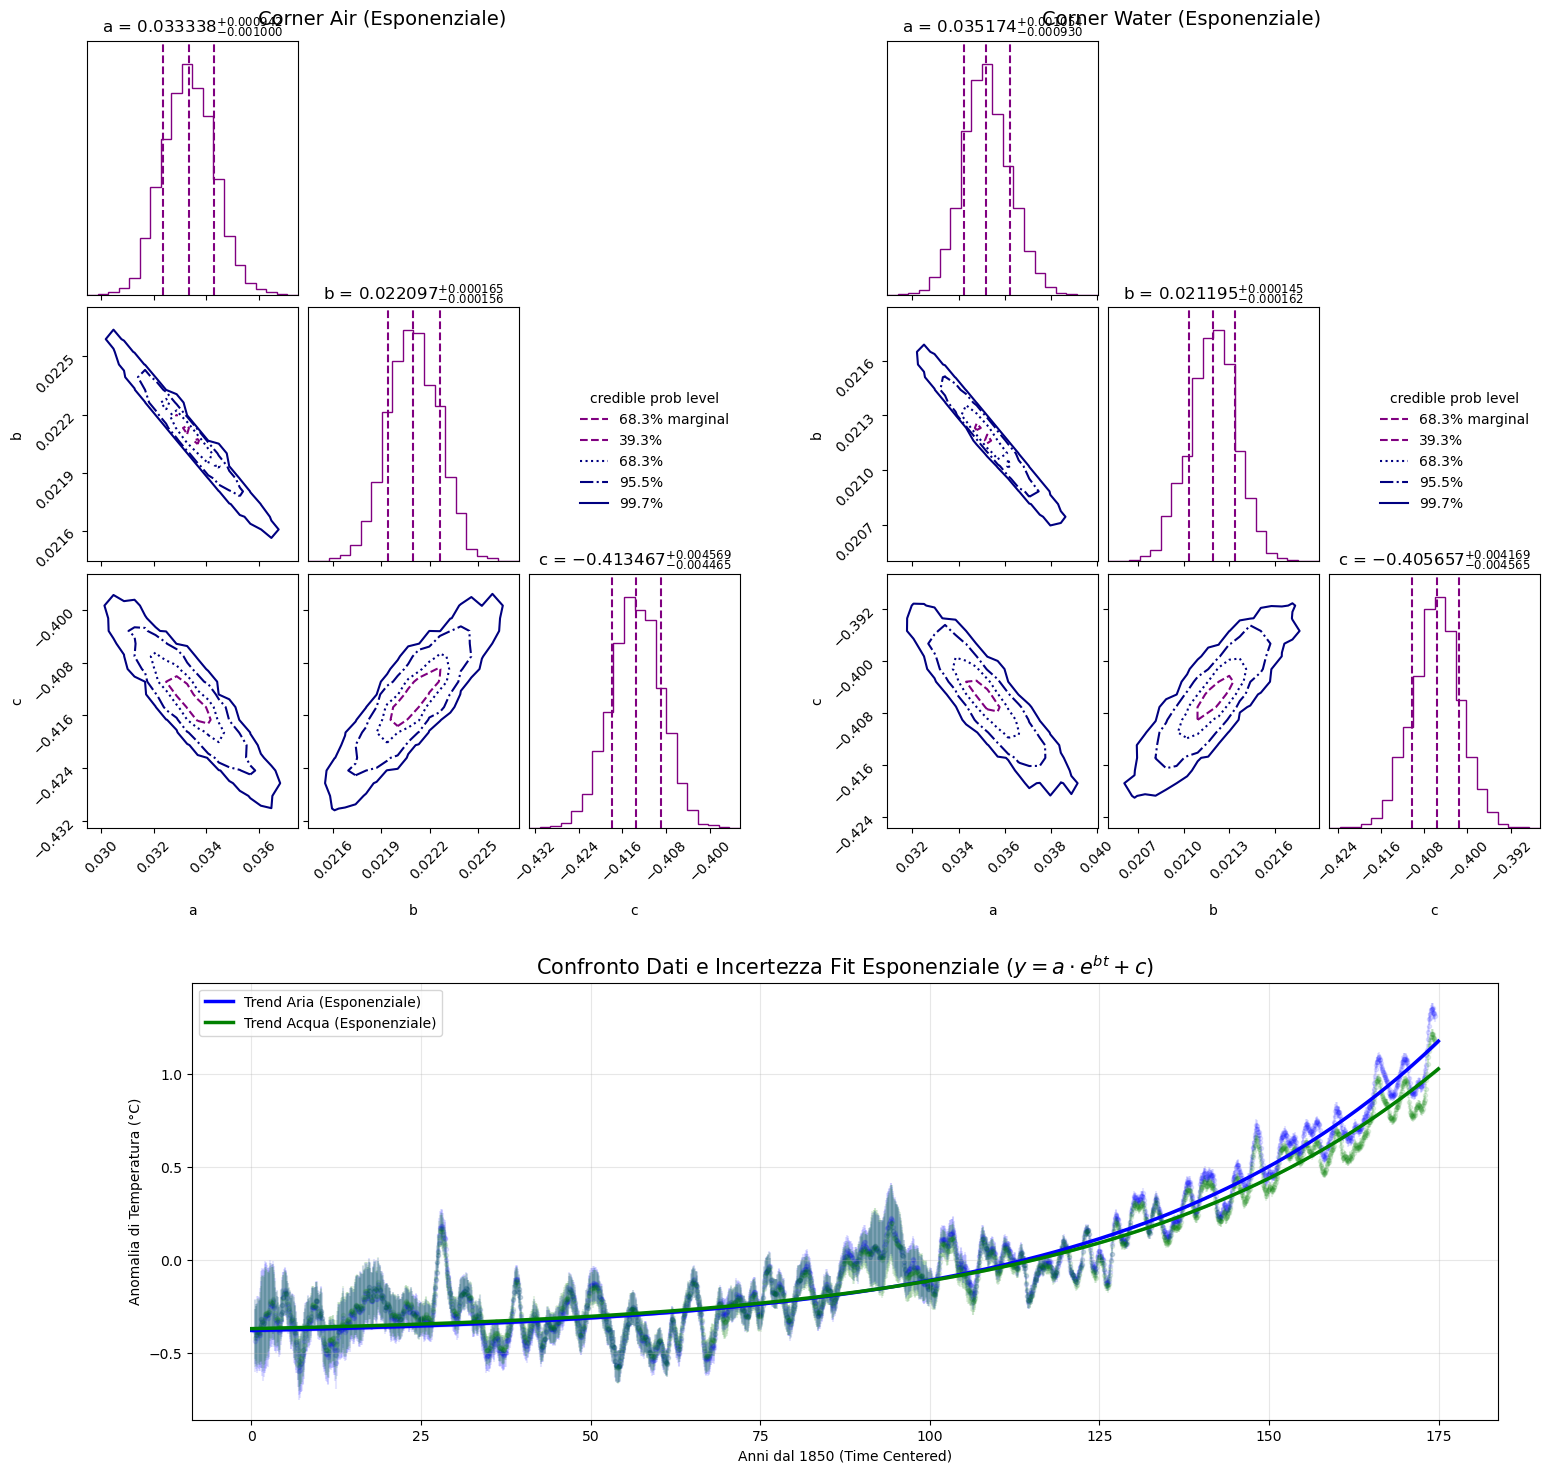

In [11]:
fig = plt.figure(figsize=(16, 15))
(subfig_top, subfig_bottom) = fig.subfigures(2, 1, height_ratios=[1.8, 1])

corner_subfigs = subfig_top.subfigures(1, 2)

cornerplot(results['air_exponential'], fig=corner_subfigs[0], title_fmt='.6f')
corner_subfigs[0].suptitle('Corner Air (Esponenziale)', fontsize=14)

cornerplot(results['water_exponential'], fig=corner_subfigs[1], title_fmt='.6f')
corner_subfigs[1].suptitle('Corner Water (Esponenziale)', fontsize=14)

ax = subfig_bottom.subplots(1, 1)

t_min = min(data_air['time_centered'].min(), data_water['time_centered'].min())
t_max = max(data_air['time_centered'].max(), data_water['time_centered'].max())
t_grid = np.linspace(t_min, t_max, 400)

def plot_exponential_with_bands(ax, data, res_key, color, label_prefix):
    samples = results[res_key]['samples']

    band = PredictionBand(t_grid)

    idx = np.random.choice(len(samples), 500, replace=False)
    for i in idx:
        a, b, c = samples[i]
        band.add(a * np.exp(b * t_grid) + c)
    
    ax.errorbar(data['time_centered'], data['Annual_Anomaly'], 
                yerr=data['Annual_Anomaly_Unc'], fmt='.', color=color, alpha=0.1, zorder=1)
    
    band.line(ax=ax, color=color, lw=2.5, label=f'Trend {label_prefix} (Esponenziale)', zorder=3)
    band.shade(ax=ax, color=color, alpha=0.3, zorder=2)         # 1-sigma (68%)
    band.shade(ax=ax, q=0.49, color=color, alpha=0.1, zorder=2)  # 2-sigma (95%)

plot_exponential_with_bands(ax, data_air, 'air_exponential', 'blue', 'Aria')
plot_exponential_with_bands(ax, data_water, 'water_exponential', 'green', 'Acqua')

ax.set_title('Confronto Dati e Incertezza Fit Esponenziale ($y = a \cdot e^{bt} + c$)', fontsize=15)
ax.set_xlabel('Anni dal 1850 (Time Centered)')
ax.set_ylabel('Anomalia di Temperatura (°C)')
ax.legend(loc='upper left')
ax.grid(alpha=0.3)

plt.show()

In [16]:
dataset_labels = ['air', 'water']
model_labels = ['const', 'linear', 'quadratic', 'exponential']

for data_l in dataset_labels:
    print(f"\n--- CONFRONTO MODELLI PER DATASET: {data_l.upper()} ---")
    print(f"{'Modello':<15} | {'logZ':<12} | {'Delta logZ':<12}")
    print("-" * 45)

    res0 = results[f"{data_l}_const"]
    logz0 = res0['logz']
    
    for mod_l in model_labels:
        res = results[f"{data_l}_{mod_l}"]
        logz = res['logz']
        delta = logz - logz0
        
        print(f"{mod_l:<15} | {logz:12.2f} | {delta:12.2f}")


--- CONFRONTO MODELLI PER DATASET: AIR ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -81425.66 |         0.00
linear          |    -20203.79 |     61221.88
quadratic       |     -2160.66 |     79265.00
exponential     |     -1701.96 |     79723.71

--- CONFRONTO MODELLI PER DATASET: WATER ---
Modello         | logZ         | Delta logZ  
---------------------------------------------
const           |    -74220.27 |         0.00
linear          |    -18248.68 |     55971.59
quadratic       |     -1971.78 |     72248.49
exponential     |     -1708.05 |     72512.22
